In [1]:
#Importar librerias necesarias
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import mnist
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Flatten, Dense
from tensorflow.keras.losses import SparseCategoricalCrossentropy

In [2]:
#Utilice mnist.load_data() para cargar el dataset de numeros escritos a mano y guardelos en la variable xtrain, ytrain, xtest, ytest
(xtrain, ytrain), (xtest, ytest) = mnist.load_data()

In [3]:
# Verificar dimensiones

print("xtrain:", xtrain.shape)


xtrain: (60000, 28, 28)


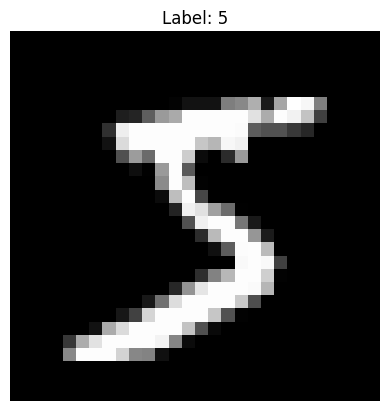

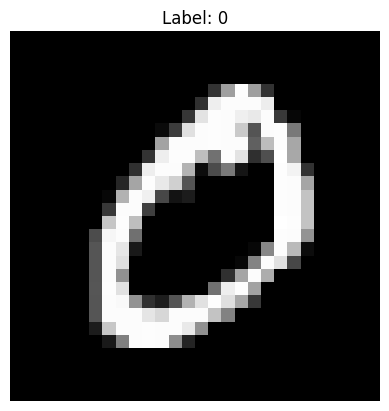

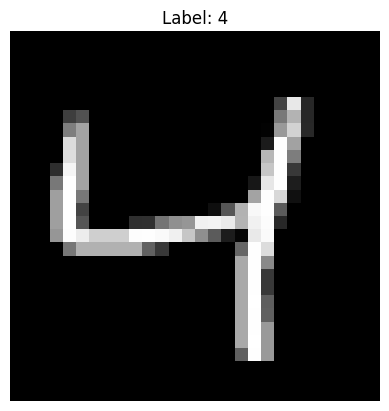

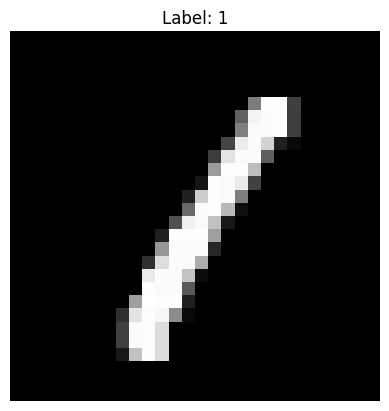

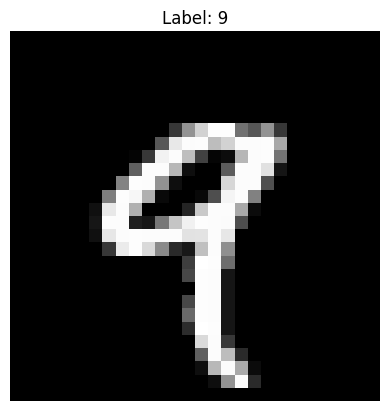

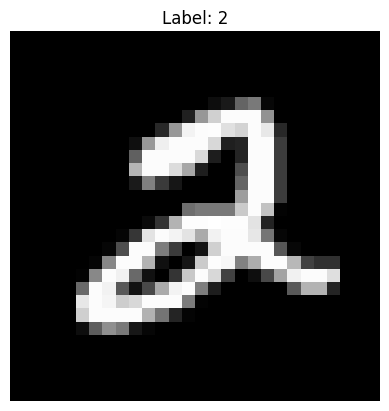

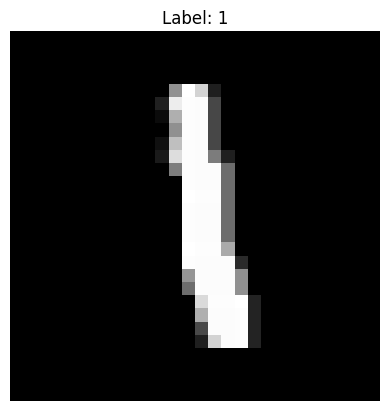

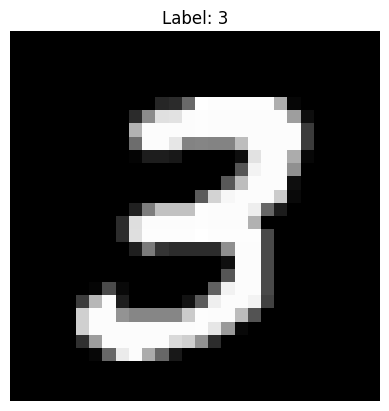

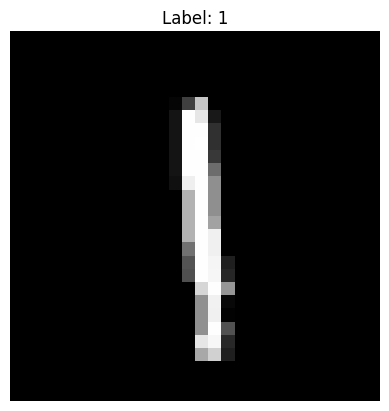

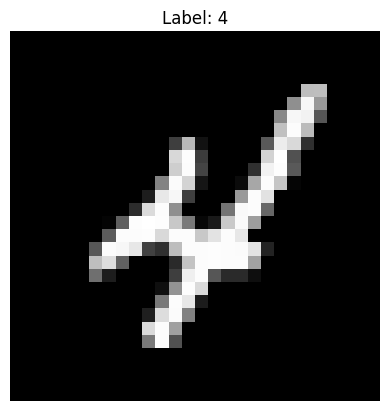

In [4]:
import matplotlib.pyplot as plt

for i in range(10):
    plt.imshow(xtrain[i], cmap='gray')
    plt.title(f"Label: {ytrain[i]}")
    plt.axis('off')
    plt.show()

In [5]:
print(xtrain[0])

[[  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   3  18  18  18 126 136
  175  26 166 255 247 127   0   0   0   0]
 [  0   0   0   0   0   0   0   0  30  36  94 154 170 253 253 253 253 253
  225 172 253 242 195  64   0   0   0   0]
 [  0   0   0   0   0   0   0  49 238 253 253 253 253 253 253 253 253 251
   93  82  82  56  39   0   0   0   0   0]
 [  0   0   0   0   0   0   0  18 219 253 253 253 253 253 198 18

In [6]:
# Normalización de imágenes
xtrain = xtrain / 255.0
xtest = xtest / 255.0

In [7]:
optimizer = Adam(learning_rate=0.01)

In [8]:
mi_modelo = Sequential([
    Flatten(input_shape=(28, 28)),
    Dense(64, activation='relu'),
    Dense(32, activation='relu'),
    Dense(16, activation='relu'),
    Dense(10, activation='relu')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [9]:
perdida = SparseCategoricalCrossentropy(from_logits=True)

In [10]:
mi_modelo.compile(
    optimizer=optimizer,
    loss=perdida,
    metrics=['accuracy']
)

In [11]:
mi_modelo.fit(
    xtrain,
    ytrain,
    epochs=20,
    validation_data=(xtest, ytest)
)

Epoch 1/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step - accuracy: 0.7844 - loss: 0.6736 - val_accuracy: 0.8538 - val_loss: 0.4209
Epoch 2/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.8584 - loss: 0.4081 - val_accuracy: 0.8645 - val_loss: 0.3836
Epoch 3/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step - accuracy: 0.8672 - loss: 0.3769 - val_accuracy: 0.8644 - val_loss: 0.3824
Epoch 4/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.8659 - loss: 0.3816 - val_accuracy: 0.8703 - val_loss: 0.3676
Epoch 5/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8718 - loss: 0.3587 - val_accuracy: 0.8629 - val_loss: 0.4048
Epoch 6/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.8745 - loss: 0.3439 - val_accuracy: 0.8635 - val_loss: 0.3814
Epoch 7/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8743 - loss: 0.3494 - val_accuracy: 0.8675 - val_loss: 0.3775
Epoch 8/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.8748 - loss: 0.3484 - 

In [12]:
mi_modelo.evaluate(xtest, ytest, verbose=2)

313/313 - 1s - 2ms/step - accuracy: 0.8699 - loss: 0.3969


[0.39687198400497437, 0.8698999881744385]

In [13]:
mi_modelo.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │        50,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │           170 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 159,056 (621.32 KB)

 Trainable params: 53,018 (207.10 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 106,038 (414.21 KB)